# Cyclic Spectroscopy Demonstration

This notebook demonstrates the calculation of the periodic correlation and the cyclic spectrum, in the following steps:

1. Simulate a pulsar (periodically amplitude-modulated noise)

2. Generate an impulse response function

6. computation of the periodic correlation

7. computation of the cyclic spectrum

At each step, a plot is produced that demonstrates the key features of the signal / function. 




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# Time & Sampling Parameters
fs = 1e6            # Sampling frequency: 1 Megasample per second (1 MHz)
dt = 1.0 / fs       # Time resolution: 1 microsecond
T = 1.0             # Total observation time: 1 second
N = int(T * fs)     # Total number of samples: 1,000,000

t = np.arange(N) * dt

## 1. Simulate a pulsar (periodically amplitude-modulated noise

The pulsar has a spin period of 1 ms and a single component with a full width at half maximum (FWHM) of 50 $\mu$s.

### 1.a) Generate one second of complex-valued normally-distributed noise, $x(t)$

Sampled every $\mu$s, this models the analytic process associated with the real-valued electric field over a bandwidth of 1 MHz.

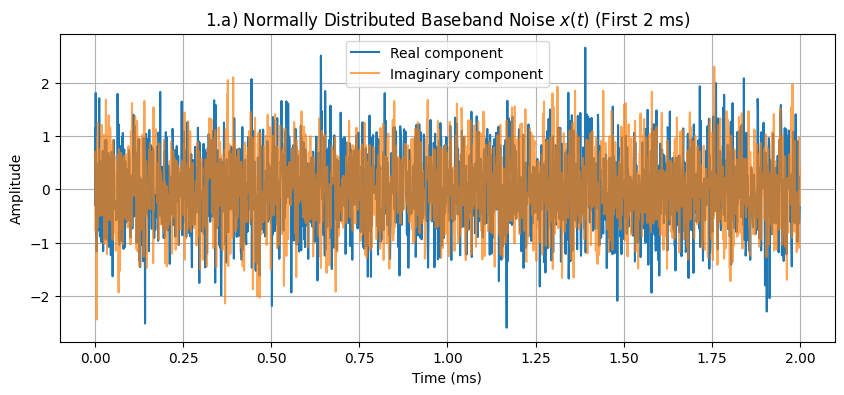

In [2]:
x = (np.random.randn(N) + 1j * np.random.randn(N)) / np.sqrt(2)

plt.figure(figsize=(10, 4))
plt.plot(t[:2000] * 1000, np.real(x[:2000]), label='Real component')
plt.plot(t[:2000] * 1000, np.imag(x[:2000]), alpha=0.7, label='Imaginary component')
plt.title("1.a) Normally Distributed Baseband Noise $x(t)$ (First 2 ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

### 1.b) Generate a periodic amplitude-modulating function, $p(t)$

A train of Gaussian pulses with a characteristic width of 50 $\mu$s, each separated by 1 ms.

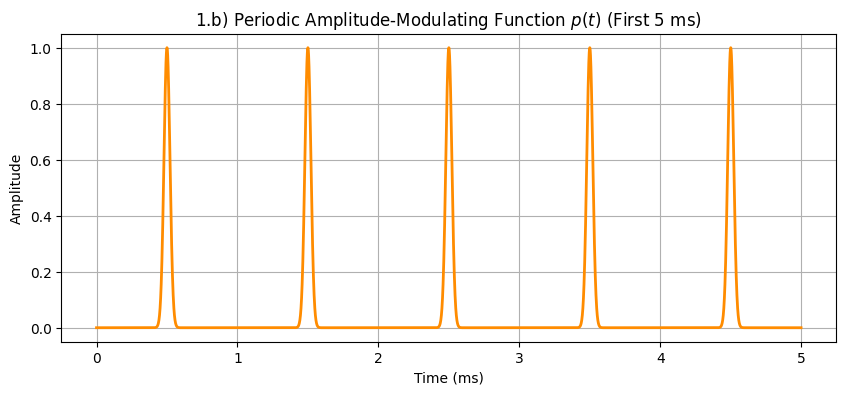

In [3]:
P = 1e-3         # Pulse period: 1 millisecond
FWHM = 50e-6     # Pulse width (full width at half maximum): 50 microseconds
sigma = FWHM / (2. * np.sqrt(2.* np.log(2.)))

# Create phase array that wraps around the period, centered at P/2
phase = ((t+0.5*P) % P)
phase[phase > P/2] -= P 

# Generate the periodic amplitude modulation profile
p = np.exp(-(phase**2) / (2 * sigma**2))

plt.figure(figsize=(10, 4))
plt.plot(t[:5000] * 1000, p[:5000], color='darkorange', linewidth=2)
plt.title("1.b) Periodic Amplitude-Modulating Function $p(t)$ (First 5 ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

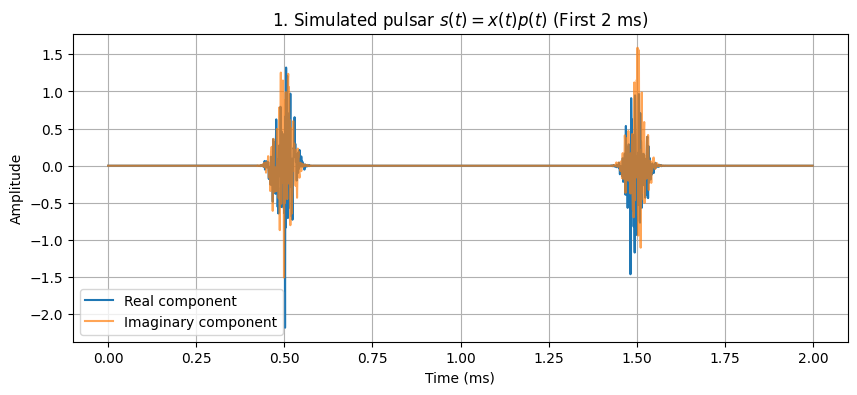

In [4]:
s = x * p
plt.figure(figsize=(10, 4))
plt.plot(t[:2000] * 1000, np.real(s[:2000]), label='Real component')
plt.plot(t[:2000] * 1000, np.imag(s[:2000]), alpha=0.7, label='Imaginary component')
plt.title("1. Simulated pulsar $s(t) = x(t) p(t)$ (First 2 ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 2. Fourier Transform of the Amplitude-Modulating Function

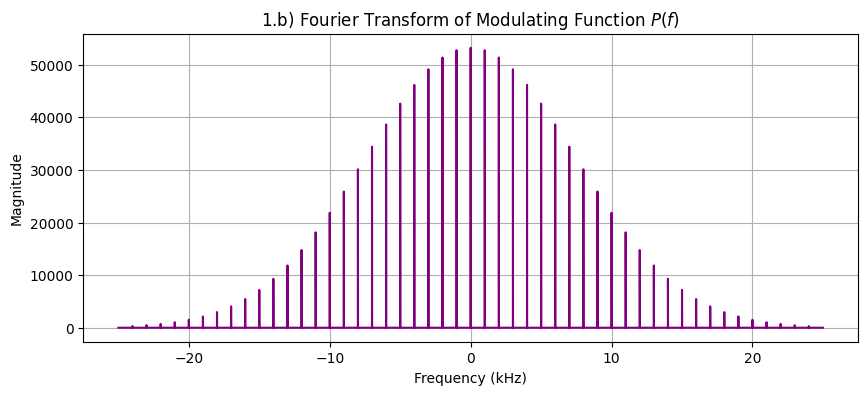

In [5]:
P_f = np.fft.fft(p)
freqs = np.fft.fftfreq(N, dt)

# Shift zero frequency to the center for plotting
P_f_shifted = np.fft.fftshift(P_f)
freqs_shifted = np.fft.fftshift(freqs)

plt.figure(figsize=(10, 4))
# Focus on the central 50 kHz to clearly see the 1 kHz harmonic spacing
mask = np.abs(freqs_shifted) < 25000 
plt.plot(freqs_shifted[mask] / 1000, np.abs(P_f_shifted[mask]), color='purple')
plt.title("1.b) Fourier Transform of Modulating Function $P(f)$")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

## 2. Generate Impulse Response Function

To simulate multipath propagation through the interstellar medium, we generate an impulse response $h(t)$ consisting of complex noise modulated by a one-sided exponential decay with a timescale of 100 $\mu$s.

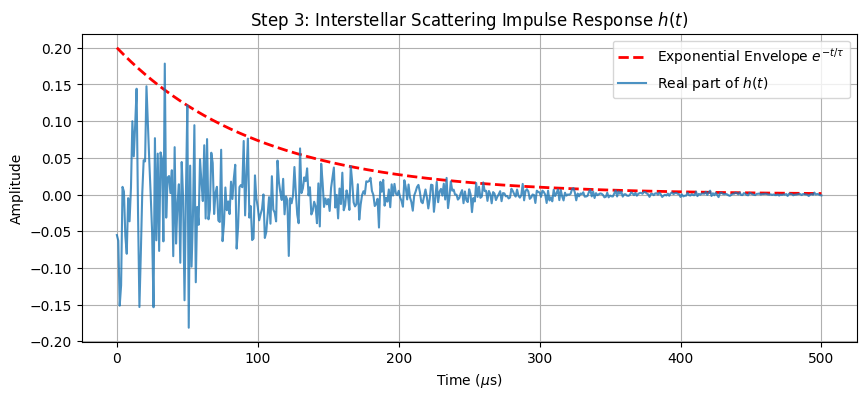

In [6]:
tau_scatter = 100e-6 # Decay timescale: 100 microseconds

# Define h(t) over a window of 5 e-foldings to capture the full decay
th = np.arange(0, 5 * tau_scatter, dt)
h_noise = (np.random.randn(len(th)) + 1j * np.random.randn(len(th))) / np.sqrt(2)
h_envelope = np.exp(-th / tau_scatter)

h = h_noise * h_envelope
h /= np.linalg.norm(h) # Normalize energy
h_envelope /= 5

plt.figure(figsize=(10, 4))
plt.plot(th * 1e6, h_envelope, 'r--', label='Exponential Envelope $e^{-t/\\tau}$', linewidth=2)
plt.plot(th * 1e6, np.real(h), label='Real part of $h(t)$', alpha=0.8)
plt.title("Step 3: Interstellar Scattering Impulse Response $h(t)$")
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

Convolving intrinsic signal with impulse response (may take a few seconds)...


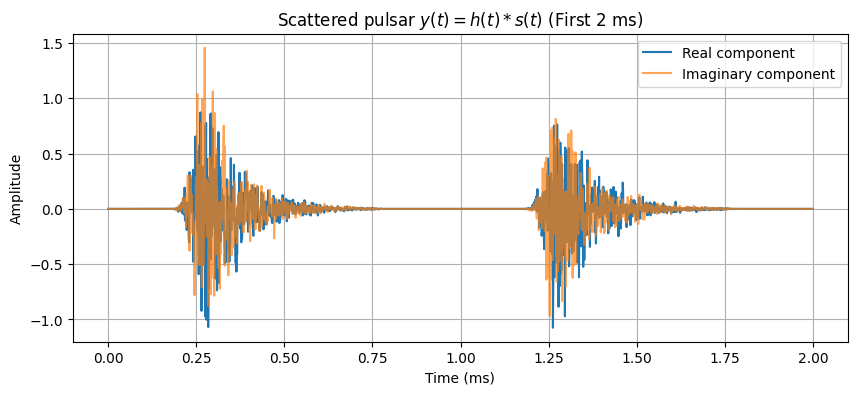

In [7]:
# 2. Convolve with the scattering impulse response
print("Convolving intrinsic signal with impulse response (may take a few seconds)...")
y = fftconvolve(s, h, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(t[:2000] * 1000, np.real(y[:2000]), label='Real component')
plt.plot(t[:2000] * 1000, np.imag(y[:2000]), alpha=0.7, label='Imaginary component')
plt.title("Scattered pulsar $y(t) = h(t) * s(t)$ (First 2 ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 3. Compute the Periodic Correlation

The periodic correlation $R(\phi, \tau) = \langle y(t) y^*(t+\tau) \rangle_{\phi = t/P}$ leverages the cyclostationarity of the signal. We estimate the expectation operator $\langle \dots \rangle$ by averaging the correlation over the 1,000 pulses in our 1-second dataset.

In [8]:
samples_per_pulse = int(P / dt)
num_pulses = int(N / samples_per_pulse)
nlag = samples_per_pulse // 2

# Reshape the unlagged signal into a matrix: (pulse_index, phase_bin)
y_folded = y.reshape(num_pulses, samples_per_pulse)

# Initialize correlation matrix R(t, tau)
# phase runs along axis 0, delay runs along axis 1
R_t_tau = np.zeros((samples_per_pulse, nlag), dtype=complex)

for lag in range(nlag):
    # Shift the time series
    # (Note: this wraps the very end of the 1-second dataset to the beginning, 
    # but over 1,000 pulses, this single boundary error is negligible)
    y_1d_lagged = np.roll(y, shift=-lag)
    
    # Reshape the lagged signal into a matrix: (pulse_index, phase_bin)
    y_lagged_folded = y_1d_lagged.reshape(num_pulses, samples_per_pulse)
    
    # Average the product over all pulses (expectation value)
    R_t_tau[:, lag] = np.mean(y_folded * np.conj(y_lagged_folded), axis=0)

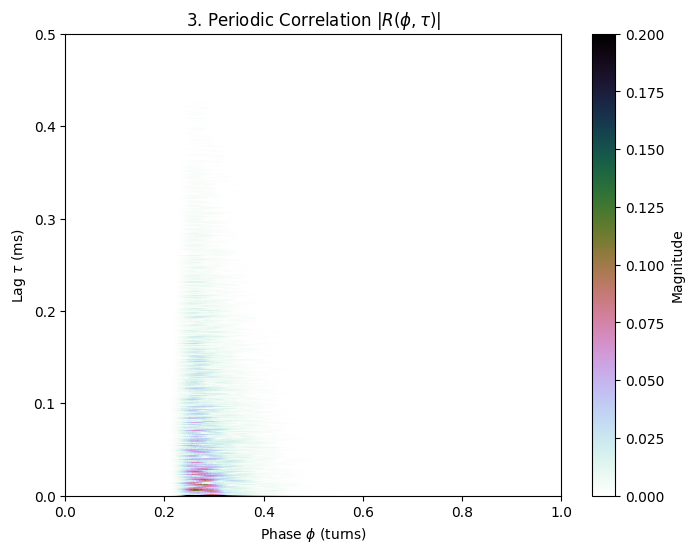

In [9]:
plt.figure(figsize=(8, 6))

max_delay_ms = nlag * dt * 1e3

# Plot magnitude of periodic correlation
plt.imshow(np.abs(R_t_tau.T), aspect='auto', origin='lower', 
           extent=[0, 1, 0, max_delay_ms], cmap='cubehelix_r', vmax=0.2, interpolation=None)
plt.title("3. Periodic Correlation $|R(\\phi, \\tau)|$")
plt.ylabel("Lag $\\tau$ (ms)")
plt.xlabel("Phase $\\phi$ (turns)")
plt.colorbar(label='Magnitude')
plt.show()

## 4. Compute the Periodic Spectrum

The Periodic Spectrum $S(\phi, \nu)$ is the 1D Fourier transform of the periodic correlation $R(\phi, \tau)$ performed over lag ($\tau$) to yield the radio frequency ($\nu$).

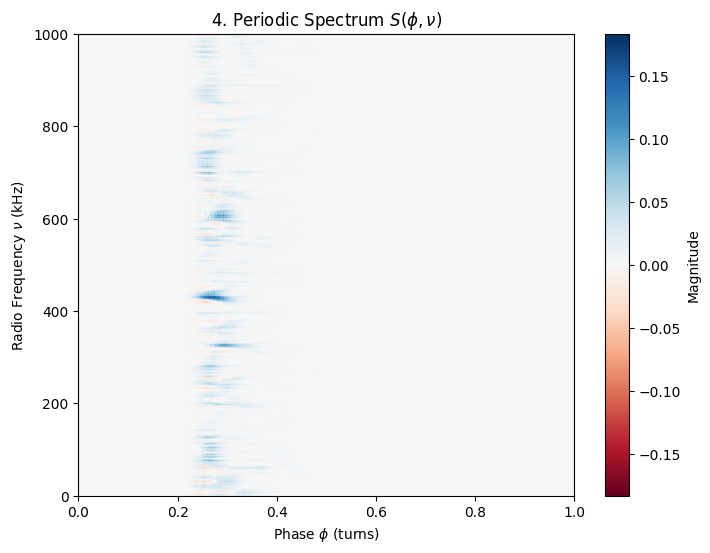

In [10]:
periodic_spectrum = np.fft.irfft(R_t_tau, axis=1, norm="ortho")

# Maximum frequency is Nyquist: (1/dt) = 1 MHz
max_freq_kHz = (1 / dt) / 1000

pmax = np.max(abs(periodic_spectrum))

plt.figure(figsize=(8, 6))
plt.imshow(periodic_spectrum.T, aspect='auto', origin='lower', 
           extent=[0, 1, 0, max_freq_kHz], cmap='RdBu', interpolation=None, vmin=-pmax, vmax=pmax)
plt.title("4. Periodic Spectrum $S(\\phi, \\nu)$")
plt.ylabel("Radio Frequency $\\nu$ (kHz)")
plt.xlabel("Phase $\\phi$ (turns)")
plt.colorbar(label='Magnitude')
plt.show()

## 5. Compute the Cyclic Spectrum

The Cyclic Spectrum $S(\alpha, \nu)$ is the 2D Fourier transform of the periodic correlation $R(t, \tau)$.  It is also the 1D Fourier transform of the periodic spectrum $S(\phi, \nu)$ performed over phase ($\phi$) to yield the cyclic frequency ($\alpha$).

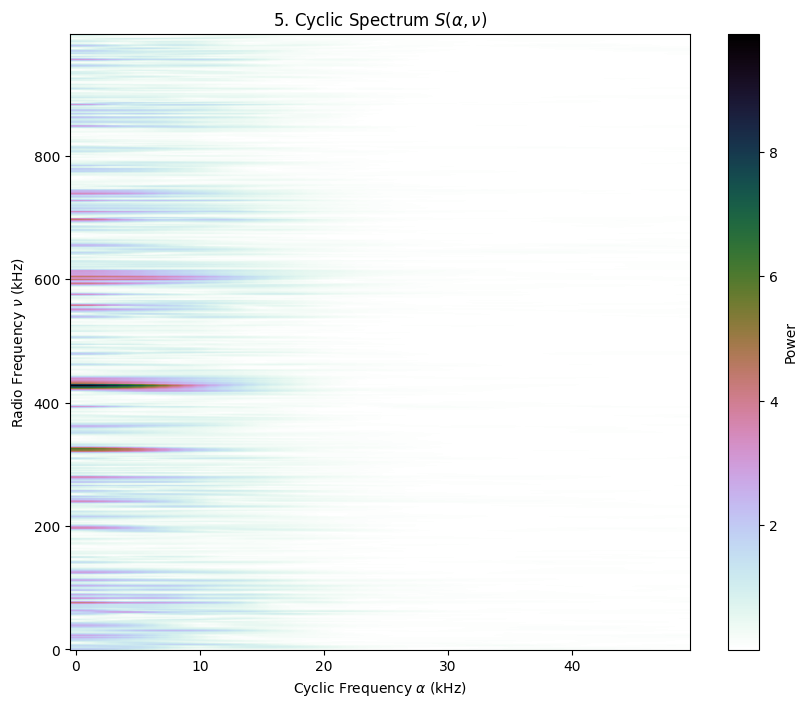

In [11]:
# 1D FFT of the periodic spectrum
S_alpha_nu = np.fft.rfft(periodic_spectrum,axis=0)

plt.figure(figsize=(10, 8))
plt.imshow(np.abs(S_alpha_nu.T)[:,:50], aspect='auto', origin='lower',
           cmap='cubehelix_r', interpolation=None)
plt.title("5. Cyclic Spectrum $S(\\alpha, \\nu)$")
plt.ylabel("Radio Frequency $\\nu$ (kHz)")
plt.xlabel("Cyclic Frequency $\\alpha$ (kHz)")
plt.colorbar(label='Power')

plt.show()